# Binomial R

Suppose we are giving two students a multiple-choice exam with 40 question? where each question has four choices. We don't know how much the students have studied for this exam, but we think that they will do better than just guessing randomly.

1. What are the parameters of interest?
2. What is our likelihood?
3. What prior should we use?
4. What is the prior probability $P(\theta>0.25)$,$P(\theta>0.5)$,$P(\theta>0.8)$?
5. Suppose the first student gets 33 questions right. What is the posterior distribution for $\theta1$?$P(\theta1>0.25)$,$P(\theta1>0.5)$,$P(\theta1>0.8)$? What is a 95% posterior credible interval for $\theta1$?
6. Suppose the second student gets 24 questions right. What is the posterior distribution for $\theta2$? $P(\theta2>0.25)$,$P(\theta2>0.5)$,$P(\theta2>0.8)$? What is a 95% posterior credible interval for $\theta2$?
7. What is the posterior probability that $\theta1>\theta2$, i.e., that the first student has a better chance of getting a question right than the second student?

## Import Libraries

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from IPython.display import display, Math, Markdown

## Solutions:

1. Parameters of interest are $\theta1 = true$ probability the first student will answer a question correctly, and $\theta2 = true$ probability the second student will answer a question correctly.
2. Likelihood is $Binomial(40,\theta)$, if we assume that each question is independent and that the probability a student gets each question right is the same for all questions for that student.
3. The conjugate prior is a beta prior. Plot the density with **scipy.stats.beta.pdf**

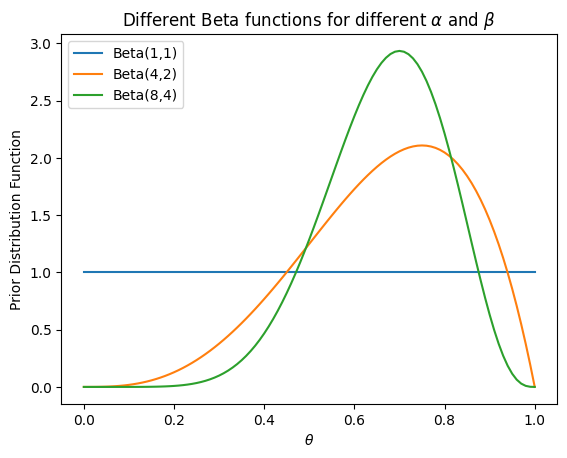

In [44]:
theta_list = np.arange(0,1.01,0.01)
beta_list1 = scipy.stats.beta.pdf(theta_list,1,1)
beta_list2 = scipy.stats.beta.pdf(theta_list,4,2)
beta_list3 = scipy.stats.beta.pdf(theta_list,8,4)
plt.plot(theta_list,beta_list1,label="Beta(1,1)")
plt.plot(theta_list,beta_list2,label="Beta(4,2)")
plt.plot(theta_list,beta_list3,label="Beta(8,4)")
plt.legend()
plt.ylabel("Prior Distribution Function")
plt.xlabel(r"$\theta$")
plt.title(r"Different Beta functions for different $\alpha$ and $\beta$")
plt.show()

The higher $\alpha$ and $\beta$ are the higer **Effective sample size**

4. Find probabilities using the **scipy.stats.beta.cdf**

In [47]:
display(Math(r"P(\theta > 0.25)"))
print(round(1 - scipy.stats.beta.cdf(0.25,8,4),3))
display(Math(r"P(\theta > 0.55)"))
print(round(1 - scipy.stats.beta.cdf(0.5,8,4),3))
display(Math(r"P(\theta > 0.8)"))
print(round(1 - scipy.stats.beta.cdf(0.8,8,4),3))

<IPython.core.display.Math object>

0.999


<IPython.core.display.Math object>

0.887


<IPython.core.display.Math object>

0.161


5. Posterior is $Beta(8+33,4+40-33) = Beta(41,11)$ 
   $$Posterior Mean = \alpha/(\alpha + \beta)$$
   $$MLE = \hat p = successes / samplesize$$

In [68]:
#Posterior Mean
41/(41+11)

0.7884615384615384

In [50]:
#MLE
33/40

0.825

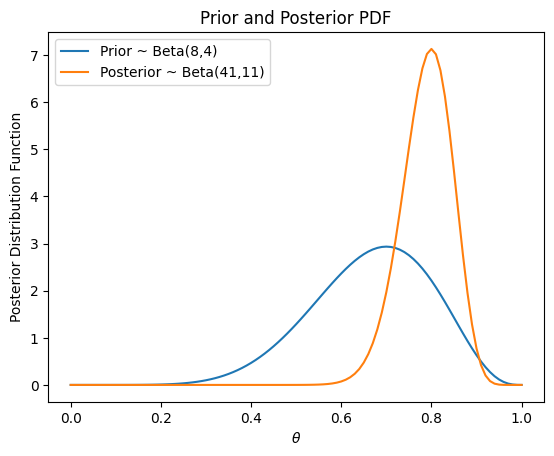

In [57]:
beta_list4 = scipy.stats.beta.pdf(theta_list,41,11)
plt.plot(theta_list,beta_list3,label="Prior ~ Beta(8,4)")
plt.plot(theta_list,beta_list4,label="Posterior ~ Beta(41,11)")
plt.legend()
plt.ylabel("Posterior Distribution Function")
plt.xlabel(r"$\theta$")
plt.title(r"Prior and Posterior PDF")
plt.show()

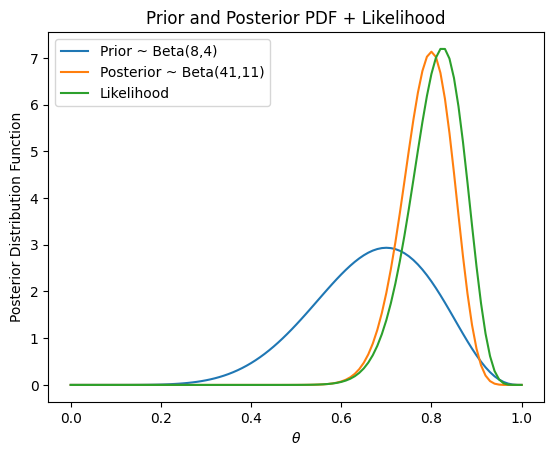

In [58]:
binom_list = 44*scipy.stats.binom.pmf(33, 40, theta_list)
plt.plot(theta_list,beta_list3,label="Prior ~ Beta(8,4)")
plt.plot(theta_list,beta_list4,label="Posterior ~ Beta(41,11)")
plt.plot(theta_list,binom_list,label="Likelihood")
plt.legend()
plt.ylabel("Posterior Distribution Function")
plt.xlabel(r"$\theta$")
plt.title(r"Prior and Posterior PDF + Likelihood")
plt.show()


In [70]:
display(Math(r"P(\theta1 > 0.25)"))
print(round(1 - scipy.stats.beta.cdf(0.25,41,11),3))
display(Math(r"P(\theta1 > 0.55)"))
print(round(1 - scipy.stats.beta.cdf(0.5,41,11),3))
display(Math(r"P(\theta1 > 0.8)"))
print(round(1 - scipy.stats.beta.cdf(0.8,41,11),3))

<IPython.core.display.Math object>

1.0


<IPython.core.display.Math object>

1.0


<IPython.core.display.Math object>

0.444


In [64]:
q1 = scipy.stats.beta.ppf(0.025, 41, 11)
print(q1)
q3 = scipy.stats.beta.ppf(0.975, 41, 11)
print(q3)

0.6688426487470711
0.8871094002502565


6. Posterior is $Beta(8+24,4+40-24) = Beta(32,20)$ 

In [67]:
#Posterior Mean
32/(32+20)

0.6153846153846154

In [66]:
#MLE
25/40

0.625

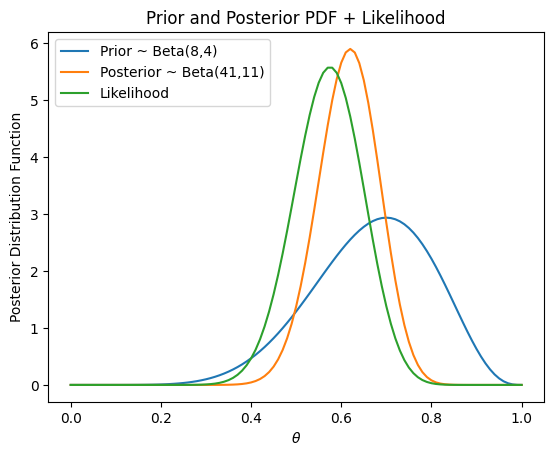

In [69]:
beta_list4 = scipy.stats.beta.pdf(theta_list,32,20)
binom_list = 44*scipy.stats.binom.pmf(23, 40, theta_list)
plt.plot(theta_list,beta_list3,label="Prior ~ Beta(8,4)")
plt.plot(theta_list,beta_list4,label="Posterior ~ Beta(41,11)")
plt.plot(theta_list,binom_list,label="Likelihood")
plt.legend()
plt.ylabel("Posterior Distribution Function")
plt.xlabel(r"$\theta$")
plt.title(r"Prior and Posterior PDF + Likelihood")
plt.show()


In [72]:
display(Math(r"P(\theta2 > 0.25)"))
print(round(1 - scipy.stats.beta.cdf(0.25,32,20),3))
display(Math(r"P(\theta2 > 0.55)"))
print(round(1 - scipy.stats.beta.cdf(0.5,32,20),3))
display(Math(r"P(\theta2 > 0.8)"))
print(round(1 - scipy.stats.beta.cdf(0.8,32,20),3))

<IPython.core.display.Math object>

1.0


<IPython.core.display.Math object>

0.954


<IPython.core.display.Math object>

0.001


In [73]:
q1 = scipy.stats.beta.ppf(0.025, 32, 20)
print(q1)
q3 = scipy.stats.beta.ppf(0.975, 32, 20)
print(q3)

0.4808021582419634
0.7415563647178172


In [74]:
sample_1 = scipy.stats.beta.rvs(41, 11, size=1000)
sample_2 = scipy.stats.beta.rvs(32, 20, size=1000)

In [78]:
(sample_1 > sample_2).mean()

np.float64(0.978)

In [79]:
1/6

0.16666666666666666

In [83]:
round(scipy.stats.beta.cdf(0.5,1,5),3)

np.float64(0.969)

In [84]:
q1 = scipy.stats.beta.ppf(0.025, 8, 16)
print(q1)
q3 = scipy.stats.beta.ppf(0.975, 8, 16)
print(q3)

0.1637635983749499
0.5291916660085066


In [85]:
display(Math(r"P(\theta2 < 0.35)"))
print(round(scipy.stats.beta.cdf(0.25,8,16),3))

<IPython.core.display.Math object>

0.196


In [86]:
display(Math(r"P(\theta2 < 0.35)"))
print(round(scipy.stats.beta.cdf(0.25,8,21),3))

<IPython.core.display.Math object>

0.4


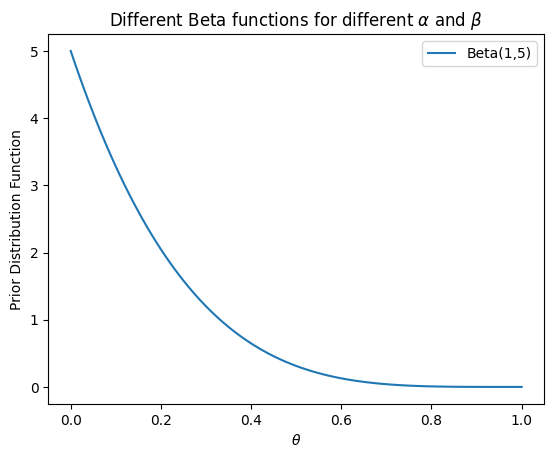

In [88]:
theta_list = np.arange(0,1.01,0.01)
bbeta = scipy.stats.beta.pdf(theta_list,1,5)
plt.plot(theta_list,bbeta,label="Beta(1,5)")
plt.legend()
plt.ylabel("Prior Distribution Function")
plt.xlabel(r"$\theta$")
plt.title(r"Different Beta functions for different $\alpha$ and $\beta$")
plt.show()